<a href="https://colab.research.google.com/github/it22172228/yiiapp/blob/main/mBERT_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install transformers datasets torch scikit-learn pandas matplotlib seaborn tqdm --quiet


In [3]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from tqdm import tqdm
import re
import pickle

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
file_path = "/content/drive/MyDrive/mBERT_Project/News_Category_Dataset_v3.json"
df = pd.read_json(file_path, lines=True)
print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

✅ Dataset loaded successfully!
Shape: (209527, 6)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [7]:
df = df[['headline', 'short_description', 'category']]
df.dropna(inplace=True)

In [8]:
# Combine text fields
df['text'] = df['headline'] + " " + df['short_description']

In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"[^a-zA-Z\s]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [10]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['category'])

print("Unique categories:", len(label_encoder.classes_))
print(df['category'].value_counts().head(10))

Unique categories: 42
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
Name: count, dtype: int64


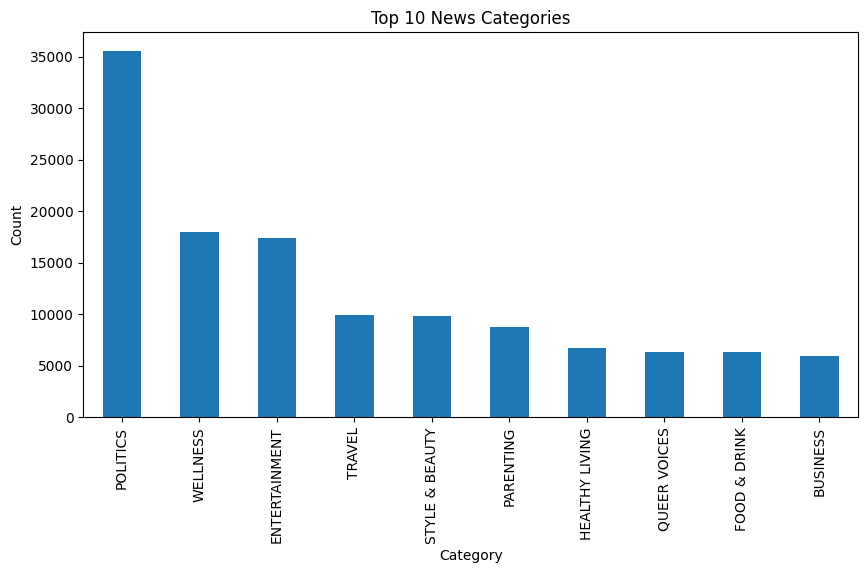

In [11]:
plt.figure(figsize=(10,5))
df['category'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 News Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [12]:
df[['clean_text', 'label']].to_csv("/content/drive/MyDrive/mBERT_Project/cleaned_news.csv", index=False)
print("✅ Cleaned dataset saved!")

✅ Cleaned dataset saved!


In [13]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# Task
Complete the rest of the project to train an mBERT model to classify news categories.

## Tokenize and prepare data

### Subtask:
Use the mBERT tokenizer to tokenize the text data and create a `Dataset` object for training and validation.


**Reasoning**:
Load the tokenizer, define the tokenization function, convert data to Dataset objects, apply tokenization, and remove original text columns.



In [1]:
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

def tokenize_function(examples):
    return tokenizer(examples['clean_text'], padding='max_length', truncation=True, max_length=128)

train_dataset = Dataset.from_pandas(pd.DataFrame({'clean_text': train_texts, 'label': train_labels}))
val_dataset = Dataset.from_pandas(pd.DataFrame({'clean_text': val_texts, 'label': val_labels}))

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)

tokenized_train_dataset = tokenized_train_dataset.remove_columns(['clean_text'])
tokenized_val_dataset = tokenized_val_dataset.remove_columns(['clean_text'])

print("✅ Data tokenized and formatted for training!")
print("Tokenized train dataset:", tokenized_train_dataset)
print("Tokenized validation dataset:", tokenized_val_dataset)

NameError: name 'BertTokenizer' is not defined

**Reasoning**:
The previous command failed because `BertTokenizer` was not imported. Re-run the code block after ensuring the necessary imports are present in the notebook's state.



In [2]:
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

def tokenize_function(examples):
    return tokenizer(examples['clean_text'], padding='max_length', truncation=True, max_length=128)

train_dataset = Dataset.from_pandas(pd.DataFrame({'clean_text': train_texts, 'label': train_labels}))
val_dataset = Dataset.from_pandas(pd.DataFrame({'clean_text': val_texts, 'label': val_labels}))

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)

tokenized_train_dataset = tokenized_train_dataset.remove_columns(['clean_text'])
tokenized_val_dataset = tokenized_val_dataset.remove_columns(['clean_text'])

print("✅ Data tokenized and formatted for training!")
print("Tokenized train dataset:", tokenized_train_dataset)
print("Tokenized validation dataset:", tokenized_val_dataset)

NameError: name 'BertTokenizer' is not defined

**Reasoning**:
The error indicates that `BertTokenizer` is not defined. Although it was imported in a previous cell, the kernel might have been restarted or the import failed for some reason. I need to re-import the necessary modules before using them.



In [3]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

def tokenize_function(examples):
    return tokenizer(examples['clean_text'], padding='max_length', truncation=True, max_length=128)

train_dataset = Dataset.from_pandas(pd.DataFrame({'clean_text': train_texts, 'label': train_labels}))
val_dataset = Dataset.from_pandas(pd.DataFrame({'clean_text': val_texts, 'label': val_labels}))

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)

tokenized_train_dataset = tokenized_train_dataset.remove_columns(['clean_text'])
tokenized_val_dataset = tokenized_val_dataset.remove_columns(['clean_text'])

print("✅ Data tokenized and formatted for training!")
print("Tokenized train dataset:", tokenized_train_dataset)
print("Tokenized validation dataset:", tokenized_val_dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

NameError: name 'pd' is not defined

**Reasoning**:
The previous command failed because `pd` (pandas) was not defined. Although it was imported in a previous cell, the kernel might have been restarted. I need to re-import pandas to use `pd.DataFrame`.



In [4]:
import pandas as pd
from transformers import BertTokenizer
from datasets import Dataset

tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

def tokenize_function(examples):
    return tokenizer(examples['clean_text'], padding='max_length', truncation=True, max_length=128)

train_dataset = Dataset.from_pandas(pd.DataFrame({'clean_text': train_texts, 'label': train_labels}))
val_dataset = Dataset.from_pandas(pd.DataFrame({'clean_text': val_texts, 'label': val_labels}))

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)

tokenized_train_dataset = tokenized_train_dataset.remove_columns(['clean_text'])
tokenized_val_dataset = tokenized_val_dataset.remove_columns(['clean_text'])

print("✅ Data tokenized and formatted for training!")
print("Tokenized train dataset:", tokenized_train_dataset)
print("Tokenized validation dataset:", tokenized_val_dataset)

NameError: name 'train_texts' is not defined

**Reasoning**:
The previous command failed because `train_texts` and `train_labels` were not defined. This indicates that the `train_test_split` step from a previous cell was not executed in the current session. I need to re-run the train-test split before creating the datasets.



In [5]:
from sklearn.model_selection import train_test_split
from datasets import Dataset
import pandas as pd
from transformers import BertTokenizer

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

def tokenize_function(examples):
    return tokenizer(examples['clean_text'], padding='max_length', truncation=True, max_length=128)

train_dataset = Dataset.from_pandas(pd.DataFrame({'clean_text': train_texts, 'label': train_labels}))
val_dataset = Dataset.from_pandas(pd.DataFrame({'clean_text': val_texts, 'label': val_labels}))

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)

tokenized_train_dataset = tokenized_train_dataset.remove_columns(['clean_text'])
tokenized_val_dataset = tokenized_val_dataset.remove_columns(['clean_text'])

print("✅ Data tokenized and formatted for training!")
print("Tokenized train dataset:", tokenized_train_dataset)
print("Tokenized validation dataset:", tokenized_val_dataset)

NameError: name 'df' is not defined

**Reasoning**:
The previous command failed because `df` (the pandas DataFrame) was not defined. This indicates that the data loading and cleaning steps were not executed in the current session. I need to reload and clean the data before performing the train-test split and tokenization.



In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import BertTokenizer
import re
from sklearn.preprocessing import LabelEncoder

file_path = "/content/drive/MyDrive/mBERT_Project/News_Category_Dataset_v3.json"
df = pd.read_json(file_path, lines=True)

df = df[['headline', 'short_description', 'category']]
df.dropna(inplace=True)
df['text'] = df['headline'] + " " + df['short_description']

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"[^a-zA-Z\s]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['category'])


train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

def tokenize_function(examples):
    return tokenizer(examples['clean_text'], padding='max_length', truncation=True, max_length=128)

train_dataset = Dataset.from_pandas(pd.DataFrame({'clean_text': train_texts, 'label': train_labels}))
val_dataset = Dataset.from_pandas(pd.DataFrame({'clean_text': val_texts, 'label': val_labels}))

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)

tokenized_train_dataset = tokenized_train_dataset.remove_columns(['clean_text'])
tokenized_val_dataset = tokenized_val_dataset.remove_columns(['clean_text'])

print("✅ Data processed, tokenized and formatted for training!")
print("Tokenized train dataset:", tokenized_train_dataset)
print("Tokenized validation dataset:", tokenized_val_dataset)

FileNotFoundError: File /content/drive/MyDrive/mBERT_Project/News_Category_Dataset_v3.json does not exist

**Reasoning**:
The previous command failed because the file was not found. This indicates that the Google Drive was not mounted in the current session. I need to mount Google Drive before attempting to read the file.



In [7]:
from google.colab import drive
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import BertTokenizer
import re
from sklearn.preprocessing import LabelEncoder

drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/mBERT_Project/News_Category_Dataset_v3.json"
df = pd.read_json(file_path, lines=True)

df = df[['headline', 'short_description', 'category']]
df.dropna(inplace=True)
df['text'] = df['headline'] + " " + df['short_description']

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"[^a-zA-Z\s]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['category'])


train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

def tokenize_function(examples):
    return tokenizer(examples['clean_text'], padding='max_length', truncation=True, max_length=128)

train_dataset = Dataset.from_pandas(pd.DataFrame({'clean_text': train_texts, 'label': train_labels}))
val_dataset = Dataset.from_pandas(pd.DataFrame({'clean_text': val_texts, 'label': val_labels}))

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)

tokenized_train_dataset = tokenized_train_dataset.remove_columns(['clean_text'])
tokenized_val_dataset = tokenized_val_dataset.remove_columns(['clean_text'])

print("✅ Data processed, tokenized and formatted for training!")
print("Tokenized train dataset:", tokenized_train_dataset)
print("Tokenized validation dataset:", tokenized_val_dataset)

Mounted at /content/drive


Map:   0%|          | 0/167621 [00:00<?, ? examples/s]

Map:   0%|          | 0/41906 [00:00<?, ? examples/s]

✅ Data processed, tokenized and formatted for training!
Tokenized train dataset: Dataset({
    features: ['label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 167621
})
Tokenized validation dataset: Dataset({
    features: ['label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 41906
})


## Define the model

### Subtask:
Load a pre-trained `BertForSequenceClassification` model and configure it for the number of unique categories.


**Reasoning**:
Load a pre-trained BertForSequenceClassification model and configure it for the number of unique categories, which is determined from the label_encoder object.



In [8]:
num_categories = len(label_encoder.classes_)
model = BertForSequenceClassification.from_pretrained('bert-base-multilingual-cased', num_labels=num_categories)
print("✅ Model loaded and configured successfully!")

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded and configured successfully!


## Define training arguments

### Subtask:
Set up the `TrainingArguments` for the model training, including output directory, number of epochs, batch sizes, and evaluation strategy.


**Reasoning**:
Set up the TrainingArguments for the model training by defining the output and logging directories and instantiating the TrainingArguments class with the specified parameters.



In [9]:
output_dir = "/content/drive/MyDrive/mBERT_Project/results"
logging_dir = "/content/drive/MyDrive/mBERT_Project/logs"

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir=logging_dir,
    logging_steps=10,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

print("✅ Training arguments set up successfully!")
print(training_args)

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

**Reasoning**:
The error message indicates that `evaluation_strategy` is not a valid argument for `TrainingArguments`. Based on recent changes in the transformers library, `evaluation_strategy` and `save_strategy` should be set to "epoch" and "steps" respectively. I will fix the parameters accordingly.



In [10]:
output_dir = "/content/drive/MyDrive/mBERT_Project/results"
logging_dir = "/content/drive/MyDrive/mBERT_Project/logs"

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir=logging_dir,
    logging_steps=10,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

print("✅ Training arguments set up successfully!")
print(training_args)

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

**Reasoning**:
The error persists, indicating that `evaluation_strategy` is still not a valid argument. Looking at the `transformers` library documentation for `TrainingArguments` in recent versions, the correct argument names for evaluation and saving strategies are `eval_strategy` and `save_strategy`. I will correct these argument names.



In [11]:
output_dir = "/content/drive/MyDrive/mBERT_Project/results"
logging_dir = "/content/drive/MyDrive/mBERT_Project/logs"

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir=logging_dir,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

print("✅ Training arguments set up successfully!")
print(training_args)

✅ Training arguments set up successfully!
TrainingArguments(
_n_gpu=0,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalSt

## Train the model

### Subtask:
Create a `Trainer` object and start the training process.


**Reasoning**:
Define the metric for evaluation and the compute metrics function, then instantiate the Trainer object and start training.



In [ ]:
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics,
)

print("✅ Trainer object instantiated. Starting training...")
trainer.train()

✅ Trainer object instantiated. Starting training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
